# AR(p) Parameter Estimation

The $\text{AR}(p)$ process is defined by,

$
\begin{align}
X_t = \sum_{i=1}^p \varphi_i X_{t-i} + \varepsilon_{t}
\end{align}
\tag{1}
$

where,

$
\begin{align}
\varepsilon_t \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{2}
$

The Yule-Walker equations are relate the AR(p) parameters $\varphi_i$ to the autocorrelation function. If zero mean is</br>
assumed it follows that,

$
\begin{align}
\rho_n = \frac{\text{E}[X_t X_{t-n}]}{\text{E}[X_t^2]}
\end{align}
\tag{3}
$

The autocorrelation functions can be shown to have the following properties,

$
\begin{align}
&\rho_0 = 1 \\
&\rho_n \leq 1 \\
&\rho_n = \rho_{-n}
\end{align}
\tag{4}
$

Define the matrices,

$
\begin{align}
\hat{r} =
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots \\
\rho_{n-1} \\
\rho_{n}
\end{bmatrix}
\end{align}
\tag{5}
$

$
\begin{align}
\hat{\Phi} =
\begin{bmatrix}
\varphi_1 \\
\varphi_2 \\
\varphi_3 \\
\vdots \\
\varphi_{n-1} \\
\varphi_{n}
\end{bmatrix}
\end{align}
\tag{6}
$

$
\begin{align}
\hat{R} =
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-2} & \rho_{n-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-3} & \rho_{n-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-4} & \rho_{n-3} \\
\vdots & \vdots  & \vdots & \ddots & \vdots & \vdots \\
\rho_{n-2} & \rho_{n-3} & \rho_{n-4} & \cdots & 1 & \rho_1 \\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & \rho_1 & 1 \\
\end{bmatrix}
\end{align}
\tag{7}
$

Then the Yule-Walker equations are given by,

$
\begin{align}
\hat{\Phi} = \hat{R}^{-1} \hat{r}
\end{align}
\tag{8}
$

## Examples

The Yule-Walker equations for $\text{AR}(1)$ is given by,

$
\begin{align}
\varphi_1 = \rho_1
\end{align}
\tag{9}
$

This is the OLS solution.

For $\text{AR}(2)$,

$
\begin{align}
\varphi_1 &= \frac{\rho_1 - \rho_1 \rho_2}{1 - \rho_1^2} \\
\varphi_2 &= \frac{\rho_2 - \rho_1^2}{1 - \rho_1^2}
\end{align}
\tag{10}
$

## Stationaity

Stationarity of an $\text{AR}(p)$ leads to convergence of the moments as $t \to \infty$. Recall the shift operator, $L$, defined by,

$
\begin{align}
&L X_t = X_{t-1} \\
&L^2 X_t = X_{t-2} \\
&L^3 X_t = X_{t-3} \\
&\vdots
\end{align}
\tag{11}
$

An $\text{AR}(p)$ process can be written as,

$
\begin{align}
\varepsilon_t = (1 - \varphi L - \varphi^2 L^2 - \varphi^3 L^3 - \cdots - \varphi^p L^p) X_t
\end{align}
\tag{12}
$

The characteristic equation is obtained by replacing $L$ with the variable $z$ and setting the result to zero,

$
\begin{align}
1 - \varphi z - \varphi^2 z^2 - \varphi^3 z^3 - \cdots - \varphi^p z^p = 0
\end{align}
\tag{13}
$

Stationarity requires that $\lvert z \rvert > 1$. To see this consider $\text{AR}(1)$. The characteristic equation is,

$
\begin{align}
1 - \varphi z = 0
\end{align}
\tag{14}
$

The solution is $z = \frac{1}{\varphi}$. It follows that stationarity requires,

$
\begin{align}
\lvert \varphi \rvert < 1
\end{align}
\tag{15}
$

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(φ_vals, title, ylim, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6), lw=1)
    return t, scan

## Simulations

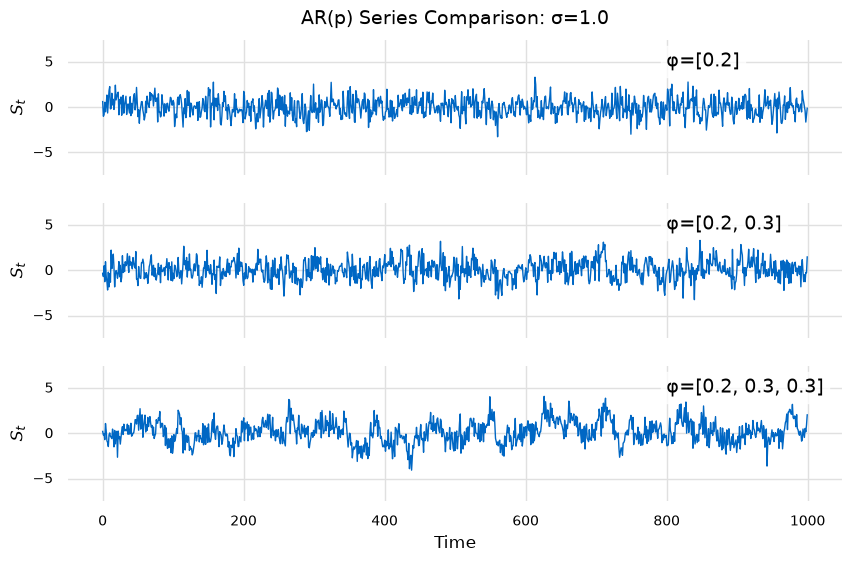

In [3]:
σ = 1.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-7.5, 7.5], *params)

## Estimation of $\text{AR}(p)$ Parameters ($\sigma = 1$)

$\text{AR}(p)$ parameters are estimated using two methods. The Yule-Walker ACF and `statsmodels.tsa.arima_model.ARMA`

### AR(1) Example $\varphi = 0.2$

In [4]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.16440047]))

In [5]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1414.788
Date:                Sun, 30 Aug 2026   AIC                           2835.577
Time:                        11:23:03   BIC                           2850.300
Sample:                             0   HQIC                          2841.173
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.038     -0.016      0.987      -0.074       0.073
ar.L1          0.1643      0.031      5.290      0.000       0.103       0.225
sigma2         0.9917      0.045     22.096      0.000       0.904       1.080
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.14
Prob(Q):                              0.85   Prob(JB):                         0.93
Heteroskedasticity (H):               0.95   Skew:                             0.02
Prob(H) (two-sided):                  0.66   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.0006184398648160379,
      "err": 0.037690288012706796,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "b1c2cca9-e167-4f24-bf51-7e1220beeea3",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.16431822238792557,
         "err": 0.0310632010340561,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "b1c2cca9-e167-4f24-bf51-7e1220beeea3",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 0.991696373044076,
      "err": 0.044881701088988486,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
  

### AR(2) Example $\varphi = [0.2, 0.3]$

In [7]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.15871579, 0.29871668]))

In [8]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1417.236
Date:                Sun, 30 Aug 2026   AIC                           2842.473
Time:                        11:23:03   BIC                           2862.104
Sample:                             0   HQIC                          2849.934
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0427      0.058      0.733      0.464      -0.071       0.157
ar.L1          0.1587      0.031      5.096      0.000       0.098       0.220
ar.L2          0.2988      0.031      9.544      0.000       0.237       0.360
sigma2         0.9964      0.044     22.579      0.000       0.910       1.083
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                 0.09
Prob(Q):                              0.69   Prob(JB):                         0.96
Heteroskedasticity (H):               1.16   Skew:                            -0.01
Prob(H) (two-sided):                  0.18   Kurtosis:                         3.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.04265199231511755,
      "err": 0.058209972805115695,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "53966057-a11f-4aad-b7ca-059dcb00ae97",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.1586592599535664,
         "err": 0.031131240720674344,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "53966057-a11f-4aad-b7ca-059dcb00ae97",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.29879778384822836,
         "err": 0.031306104967839296,
         "est_label": "$\\hat{\\varphi_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{2}}}$",
         "row": 0,
         "column": 0,
        

### AR(3) Example $\varphi = [0.2, 0.3, 0.3]$

In [10]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.23971831, 0.28262645, 0.27055494]))

In [11]:
result, result_model = arima.compute_ar_estimate(ar[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1346.823
Date:                Sun, 30 Aug 2026   AIC                           2703.646
Time:                        11:23:03   BIC                           2728.185
Sample:                             0   HQIC                          2712.972
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1491      0.143      1.044      0.297      -0.131       0.429
ar.L1          0.2395      0.031      7.646      0.000       0.178       0.301
ar.L2          0.2831      0.030      9.335      0.000       0.224       0.343
ar.L3          0.2703      0.031      8.835      0.000       0.210       0.330
sigma2         0.8649      0.039     22.438      0.000       0.789       0.940
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.02
Prob(Q):                              0.97   Prob(JB):                         0.99
Heteroskedasticity (H):               1.10   Skew:                            -0.00
Prob(H) (two-sided):                  0.40   Kurtosis:                         3.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.14913857028308353,
      "err": 0.14291921981770592,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "5fb164a8-581c-403f-87b4-d4bcc0102f77",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.23946554373842877,
         "err": 0.03131701609775804,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "5fb164a8-581c-403f-87b4-d4bcc0102f77",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.28308386740899605,
         "err": 0.030325274605827842,
         "est_label": "$\\hat{\\varphi_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{2}}}$",
         "row": 0,
         "column": 0,
         

## Simulations $\sigma = 5.0$

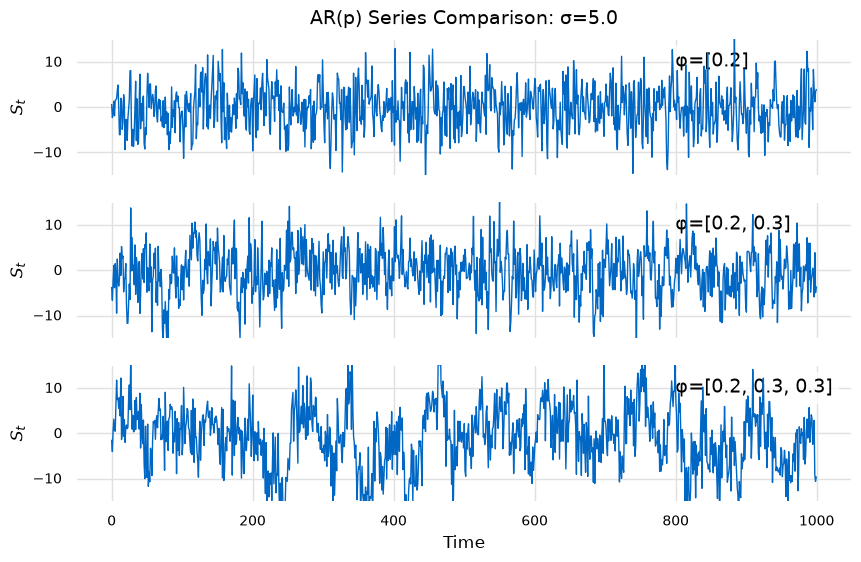

In [13]:
σ = 5.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-15.0, 15.0], *params)

### AR(1) Example ($\varphi = 0.2$)

In [14]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.1800826]))

In [15]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2997.591
Date:                Sun, 30 Aug 2026   AIC                           6001.182
Time:                        11:23:04   BIC                           6015.906
Sample:                             0   HQIC                          6006.778
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2384      0.187     -1.274      0.203      -0.605       0.128
ar.L1          0.1800      0.030      5.915      0.000       0.120       0.240
sigma2        23.5060      1.023     22.985      0.000      21.502      25.510
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.80
Prob(Q):                              0.96   Prob(JB):                         0.67
Heteroskedasticity (H):               1.02   Skew:                             0.01
Prob(H) (two-sided):                  0.83   Kurtosis:                         3.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.23836321258474372,
      "err": 0.18706457593672707,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "c1ebb68f-abdf-4025-837c-e0cf6d73efa8",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.18003769602219802,
         "err": 0.0304386015411335,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c1ebb68f-abdf-4025-837c-e0cf6d73efa8",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 23.505972746483618,
      "err": 1.02267272916768,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "e

### AR(2) Example ($\varphi = [0.2, 0.3]$)

In [17]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.19382697, 0.26665058]))

In [18]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -3001.602
Date:                Sun, 30 Aug 2026   AIC                           6011.204
Time:                        11:23:04   BIC                           6030.835
Sample:                             0   HQIC                          6018.665
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3945      0.287     -1.376      0.169      -0.956       0.167
ar.L1          0.1939      0.032      6.003      0.000       0.131       0.257
ar.L2          0.2671      0.030      8.834      0.000       0.208       0.326
sigma2        23.6910      1.050     22.555      0.000      21.632      25.750
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.14
Prob(Q):                              0.91   Prob(JB):                         0.93
Heteroskedasticity (H):               0.90   Skew:                            -0.00
Prob(H) (two-sided):                  0.34   Kurtosis:                         3.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.3945163956092827,
      "err": 0.2866224640926413,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "c93f38a3-de62-4a25-be25-2720ab3c8bb9",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.19387401585667163,
         "err": 0.03229383472643505,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c93f38a3-de62-4a25-be25-2720ab3c8bb9",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.2670904012901418,
         "err": 0.030235617758284893,
         "est_label": "$\\hat{\\varphi_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{2}}}$",
         "row": 0,
         "column": 0,
         "o

### AR(3) Example ($\varphi = [0.2, 0.3, 0.3]$)

In [20]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.21748353, 0.26386535, 0.32666684]))

In [21]:
result, result_model = arima.compute_ar_estimate(ar[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -3001.510
Date:                Sun, 30 Aug 2026   AIC                           6013.021
Time:                        11:23:04   BIC                           6037.560
Sample:                             0   HQIC                          6022.347
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3941      0.283     -1.390      0.164      -0.950       0.161
ar.L1          0.1975      0.033      5.912      0.000       0.132       0.263
ar.L2          0.2697      0.031      8.706      0.000       0.209       0.330
ar.L3         -0.0135      0.033     -0.407      0.684      -0.079       0.052
sigma2        23.6870      1.054     22.483      0.000      21.622      25.752
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.12
Prob(Q):                              0.99   Prob(JB):                         0.94
Heteroskedasticity (H):               0.90   Skew:                             0.00
Prob(H) (two-sided):                  0.34   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.3941199034818235,
      "err": 0.2834576768267333,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "92c8e60a-7cc6-46ca-bea7-43a1b8633cbd",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.1975150825822331,
         "err": 0.03340668977550317,
         "est_label": "$\\hat{\\varphi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "92c8e60a-7cc6-46ca-bea7-43a1b8633cbd",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.2697431964167181,
         "err": 0.030982555219344662,
         "est_label": "$\\hat{\\varphi_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\varphi_{2}}}$",
         "row": 0,
         "column": 0,
         "or